In [2]:
from google.colab import files

uploaded = files.upload()

Saving Efficient housing mozambique 511 (1).xlsx to Efficient housing mozambique 511 (1).xlsx


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
import os

os.listdir()

['.config', 'Efficient housing mozambique 511 (1).xlsx', 'sample_data']

In [6]:
file_path = "Efficient housing mozambique 511 (1).xlsx"

excel_file = pd.ExcelFile(file_path)

excel_file.sheet_names

['Summary',
 'prices and other data',
 'Cool   Reflective Roof Coating',
 'Ceiling Installation + Roof Ins',
 'Cross Ventilation Improvements',
 'External Shading (Awnings, Over',
 'Efficient Fans (DC or Energy-Ef',
 ' financing total',
 'Sensitivity analysis',
 'Efficient buildings']

In [8]:
summary = pd.read_excel(file_path, sheet_name="Summary", header=None)

summary.head(20)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Investments,Actual Investment ('000 MZK),ENPV ('000 MZK),EIRR (%),FNPV ('000 MZK),FIRR (%),BM implementation,NaN,NaN,NaN,NaN,NaN,NaN
2,A. Total investment in various activity (Addit...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Cool / Reflective Roof Coating,5650,4963.998002,0.252356,5496.921191,0.284367,1220.707965,NaN,NaN,NaN,Total financing= US$ 11million,35 Million,NaN
4,Ceiling Installation + Roof Insulation,12188,255.14191,0.169452,1846.342989,0.161781,471.570397,NaN,NaN,NaN,Total(MZK),2299000000,NaN
5,Cross Ventilation Improvements,5106.21,25219.692948,0.123973,25219.692948,0.22401,450.236085,NaN,NaN,NaN,Additional financing,budget(MZK),Budget(%)
6,"External Shading (Awnings, Overhangs, Trees)",360,489.894402,0.307693,905.001805,0.323004,15965.277778,NaN,NaN,NaN,Cool / Reflective Roof Coating,689700000,0.3
7,"Efficient Fans (DC or Energy-Efficient Fans, S...",7043.9,2348.908514,0.201463,5643.344526,0.217269,326.381692,NaN,NaN,NaN,Ceiling Installation + Roof Insulation,574750000,0.25
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cross Ventilation Improvements,229900000,0.1
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"External Shading (Awnings, Overhangs, Trees)",574750000,0.25


In [9]:
import pandas as pd

data = {
    "Intervention": [
        "Cool Reflective Roof",
        "Ceiling + Roof Insulation",
        "Cross Ventilation",
        "External Shading",
        "Efficient Fans"
    ],

    "Investment_MZN": [
        5650,
        12188,
        5106.21,
        360,
        7043.9
    ],

    "EIRR": [
        25.23,
        16.95,
        12.39,
        30.77,
        20.15
    ],

    "FIRR": [
        28.44,
        16.18,
        22.40,
        32.30,
        21.73
    ]
}

df = pd.DataFrame(data)

df

,Intervention,Investment_MZN,EIRR,FIRR
0,Cool Reflective Roof,5650.00,25.23,28.44
1,Ceiling + Roof Insulation,12188.00,16.95,16.18
2,Cross Ventilation,5106.21,12.39,22.40
3,External Shading,360.00,30.77,32.30
4,Efficient Fans,7043.90,20.15,21.73


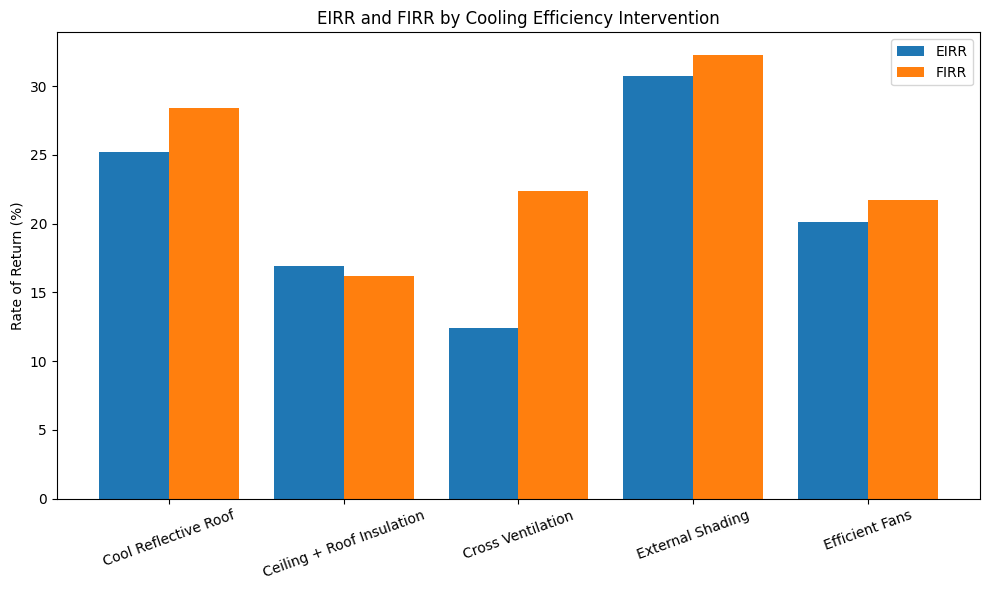

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

x = range(len(df))

plt.bar(x, df["EIRR"], width=0.4, label="EIRR")
plt.bar([i + 0.4 for i in x], df["FIRR"], width=0.4, label="FIRR")

plt.xticks([i + 0.2 for i in x], df["Intervention"], rotation=20)

plt.ylabel("Rate of Return (%)")
plt.title("EIRR and FIRR by Cooling Efficiency Intervention")

plt.legend()

plt.tight_layout()

plt.show()

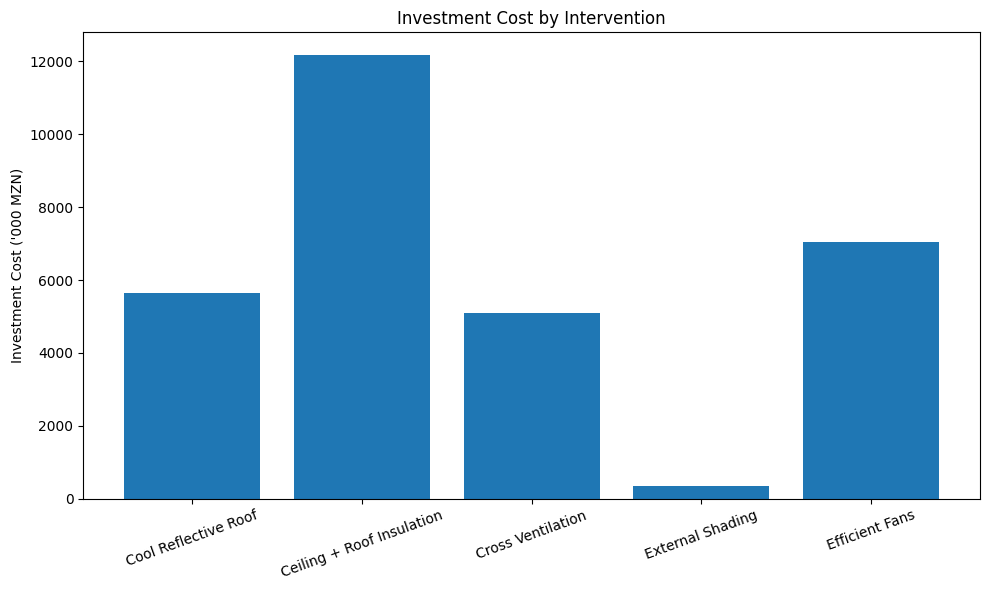

In [11]:
plt.figure(figsize=(10,6))

plt.bar(df["Intervention"], df["Investment_MZN"])

plt.ylabel("Investment Cost ('000 MZN)")
plt.title("Investment Cost by Intervention")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

Python can be used to extend the Excel-based EFA by running Monte Carlo simulations around key uncertain parameters such as investment cost, energy savings, electricity tariff, OPEX, and implementation delay. This allows the analysis to estimate the probability that ENPV remains positive under different risk scenarios.”

Monte Carlo simulation

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [13]:
import os

os.listdir()

['.config', 'Efficient housing mozambique 511 (1).xlsx', 'sample_data']

In [14]:
file_path = "Efficient housing mozambique 511 (1).xlsx"

excel_file = pd.ExcelFile(file_path)

excel_file.sheet_names

['Summary',
 'prices and other data',
 'Cool   Reflective Roof Coating',
 'Ceiling Installation + Roof Ins',
 'Cross Ventilation Improvements',
 'External Shading (Awnings, Over',
 'Efficient Fans (DC or Energy-Ef',
 ' financing total',
 'Sensitivity analysis',
 'Efficient buildings']

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Monte Carlo Simulation Setup
# -----------------------------

np.random.seed(42)

n_simulations = 10000

# From your model summary
baseline_enpv = 33277635.78   # '000 MZN
baseline_fnpv = 39111303.46   # '000 MZN
baseline_eirr = 0.1395        # 13.95%
baseline_firr = 0.1594        # 15.94%

# Assumptions:
# Cost may vary from -10% to +20%
# Revenue/savings may vary from -20% to +15%
# Delay impact may reduce value by 0% to 15%

cost_shock = np.random.uniform(-0.10, 0.20, n_simulations)
revenue_shock = np.random.uniform(-0.20, 0.15, n_simulations)
delay_shock = np.random.uniform(0.00, 0.15, n_simulations)

# Simulated ENPV and FNPV
simulated_enpv = baseline_enpv * (1 + revenue_shock) * (1 - delay_shock) - (baseline_enpv * cost_shock)
simulated_fnpv = baseline_fnpv * (1 + revenue_shock) * (1 - delay_shock) - (baseline_fnpv * cost_shock)

# Simulated EIRR and FIRR
simulated_eirr = baseline_eirr * (1 + revenue_shock - cost_shock - delay_shock)
simulated_firr = baseline_firr * (1 + revenue_shock - cost_shock - delay_shock)

results = pd.DataFrame({
    "Simulated_ENPV": simulated_enpv,
    "Simulated_FNPV": simulated_fnpv,
    "Simulated_EIRR": simulated_eirr,
    "Simulated_FIRR": simulated_firr
})

results.head()

,Simulated_ENPV,Simulated_FNPV,Simulated_EIRR,Simulated_FIRR
0,2.717095e+07,3.193409e+07,0.112843,0.128941
1,2.349197e+07,2.761018e+07,0.098156,0.112158
2,2.320294e+07,2.727048e+07,0.096263,0.109996
3,2.769384e+07,3.254865e+07,0.116267,0.132853
4,3.161705e+07,3.715961e+07,0.132204,0.151063


In [16]:
summary_stats = results.describe()
summary_stats

,Simulated_ENPV,Simulated_FNPV,Simulated_EIRR,Simulated_FIRR
count,1.000000e+04,1.000000e+04,10000.000000,10000.000000
mean,2.845876e+07,3.344767e+07,0.119040,0.136021
std,4.490991e+06,5.278275e+06,0.019619,0.022418
min,1.668778e+07,1.961320e+07,0.066306,0.075764
25%,2.519432e+07,2.961096e+07,0.104761,0.119705
50%,2.845829e+07,3.344711e+07,0.119193,0.136196
75%,3.165281e+07,3.720164e+07,0.133087,0.152072
max,4.074817e+07,4.789144e+07,0.170989,0.195381


In [17]:
prob_enpv_positive = (results["Simulated_ENPV"] > 0).mean()
prob_fnpv_positive = (results["Simulated_FNPV"] > 0).mean()
prob_eirr_above_10 = (results["Simulated_EIRR"] > 0.10).mean()
prob_firr_above_10 = (results["Simulated_FIRR"] > 0.10).mean()

print("Probability ENPV > 0:", round(prob_enpv_positive * 100, 2), "%")
print("Probability FNPV > 0:", round(prob_fnpv_positive * 100, 2), "%")
print("Probability EIRR > 10%:", round(prob_eirr_above_10 * 100, 2), "%")
print("Probability FIRR > 10%:", round(prob_firr_above_10 * 100, 2), "%")

Probability ENPV > 0: 100.0 %
Probability FNPV > 0: 100.0 %
Probability EIRR > 10%: 81.86 %
Probability FIRR > 10%: 94.44 %


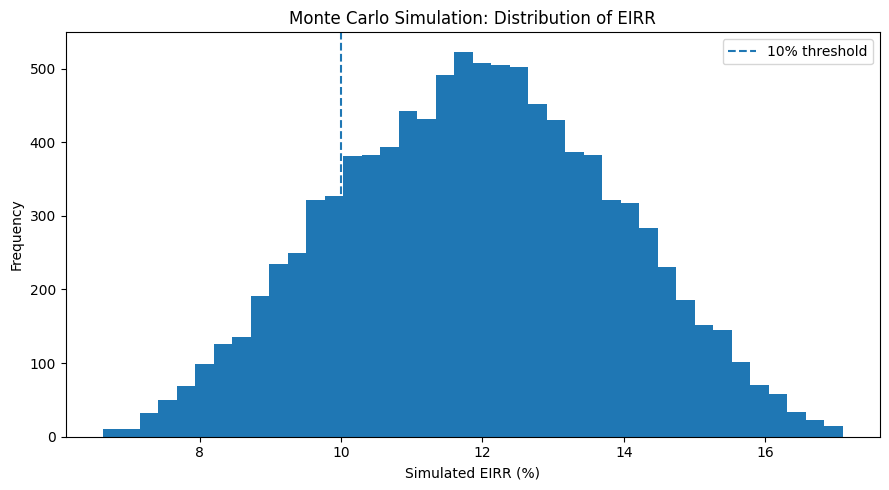

In [18]:
plt.figure(figsize=(9,5))
plt.hist(results["Simulated_EIRR"] * 100, bins=40)
plt.axvline(10, linestyle="--", label="10% threshold")
plt.xlabel("Simulated EIRR (%)")
plt.ylabel("Frequency")
plt.title("Monte Carlo Simulation: Distribution of EIRR")
plt.legend()
plt.tight_layout()
plt.show()

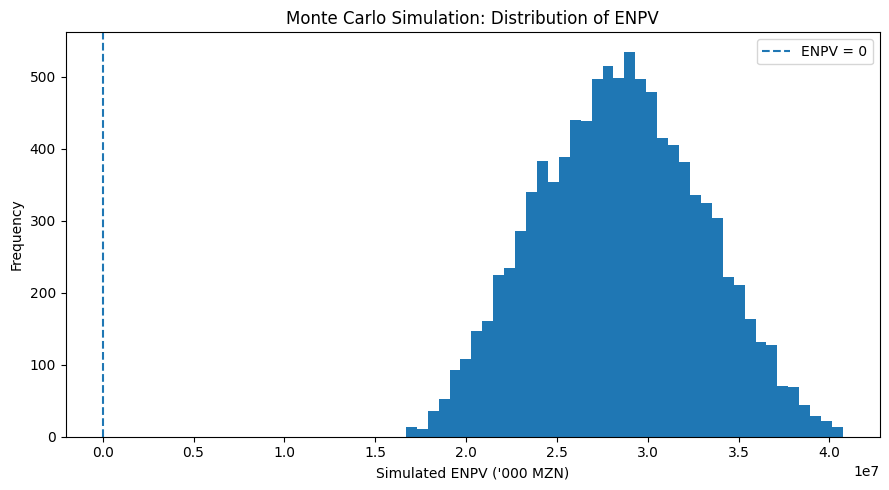

In [19]:
plt.figure(figsize=(9,5))
plt.hist(results["Simulated_ENPV"], bins=40)
plt.axvline(0, linestyle="--", label="ENPV = 0")
plt.xlabel("Simulated ENPV ('000 MZN)")
plt.ylabel("Frequency")
plt.title("Monte Carlo Simulation: Distribution of ENPV")
plt.legend()
plt.tight_layout()
plt.show()

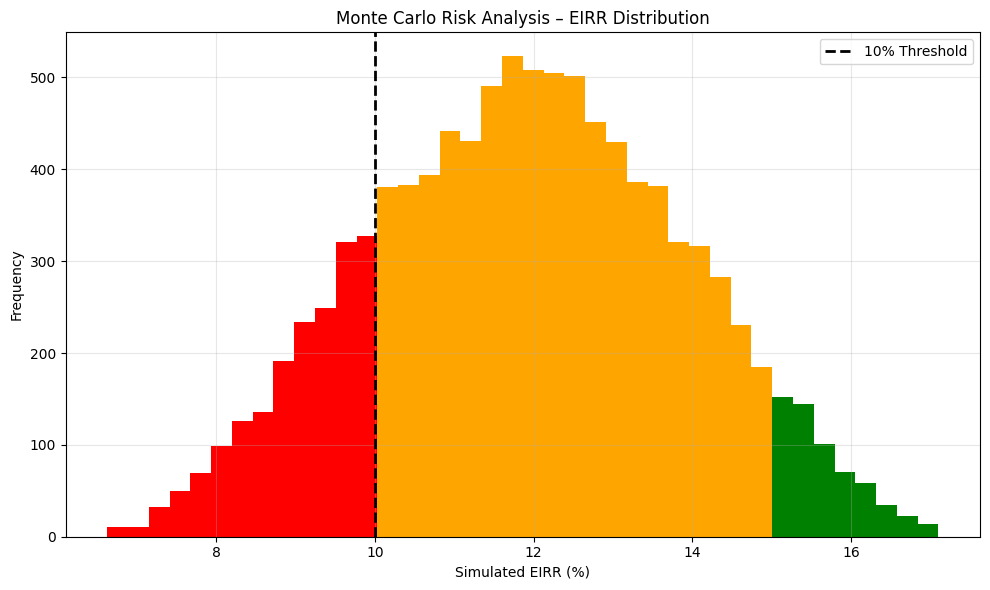

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Histogram
n, bins, patches = plt.hist(results["Simulated_EIRR"] * 100, bins=40)

# Color bars by risk level
for i in range(len(patches)):

    if bins[i] < 10:
        patches[i].set_facecolor("red")      # High risk
    elif bins[i] < 15:
        patches[i].set_facecolor("orange")   # Moderate risk
    else:
        patches[i].set_facecolor("green")    # Low risk

# Threshold line
plt.axvline(10, color='black', linestyle='--', linewidth=2, label='10% Threshold')

plt.xlabel("Simulated EIRR (%)")
plt.ylabel("Frequency")
plt.title("Monte Carlo Risk Analysis – EIRR Distribution")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

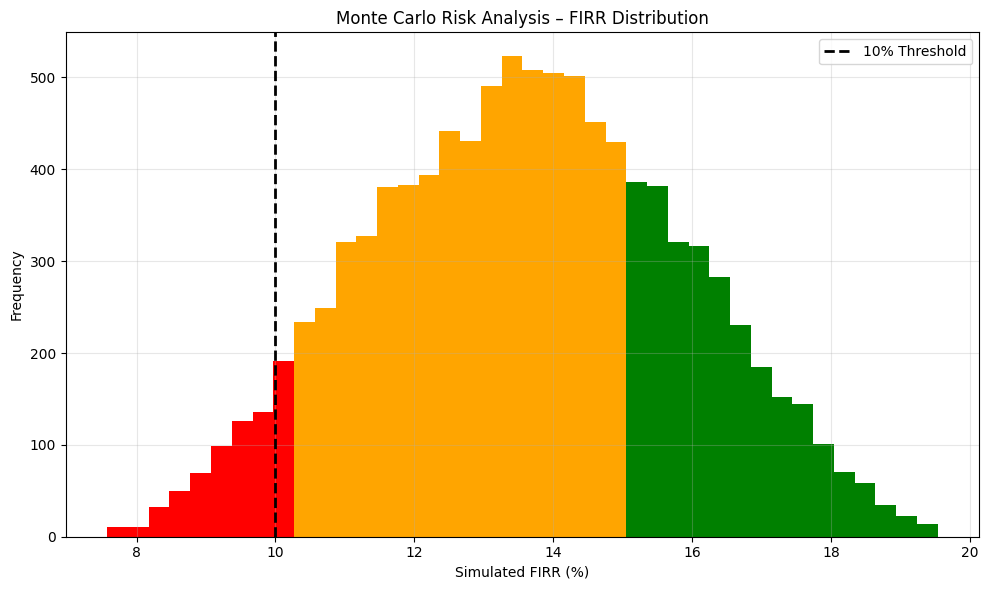

In [21]:
plt.figure(figsize=(10,6))

n, bins, patches = plt.hist(results["Simulated_FIRR"] * 100, bins=40)

for i in range(len(patches)):

    if bins[i] < 10:
        patches[i].set_facecolor("red")
    elif bins[i] < 15:
        patches[i].set_facecolor("orange")
    else:
        patches[i].set_facecolor("green")

plt.axvline(10, color='black', linestyle='--', linewidth=2, label='10% Threshold')

plt.xlabel("Simulated FIRR (%)")
plt.ylabel("Frequency")
plt.title("Monte Carlo Risk Analysis – FIRR Distribution")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

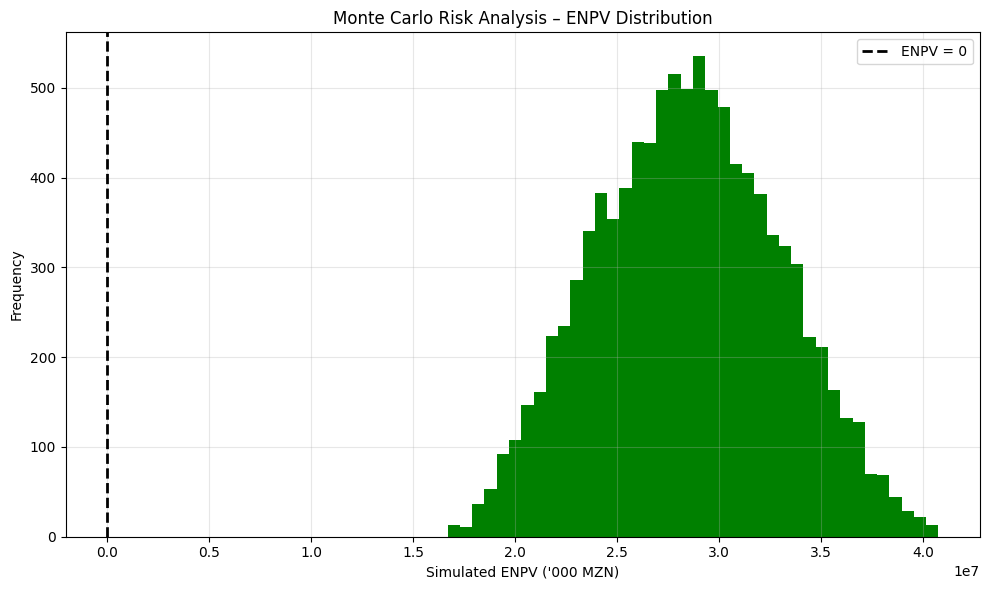

In [22]:
plt.figure(figsize=(10,6))

n, bins, patches = plt.hist(results["Simulated_ENPV"], bins=40)

for i in range(len(patches)):

    if bins[i] < 0:
        patches[i].set_facecolor("red")
    else:
        patches[i].set_facecolor("green")

plt.axvline(0, color='black', linestyle='--', linewidth=2, label='ENPV = 0')

plt.xlabel("Simulated ENPV ('000 MZN)")
plt.ylabel("Frequency")

plt.title("Monte Carlo Risk Analysis – ENPV Distribution")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [23]:
plt.style.use('ggplot')

In [24]:
plt.style.use('seaborn-v0_8')

| Color  | Meaning                     |
| ------ | --------------------------- |
| Red    | High risk / below threshold |
| Orange | Moderate risk               |
| Green  | Acceptable / viable         |


Probability ENPV > 0: 100.0 %
Probability FNPV > 0: 100.0 %
Probability EIRR > 10%: 81.86 %
Probability FIRR > 10%: 94.44 %

Mean EIRR: 11.9 %
Mean FIRR: 13.6 %


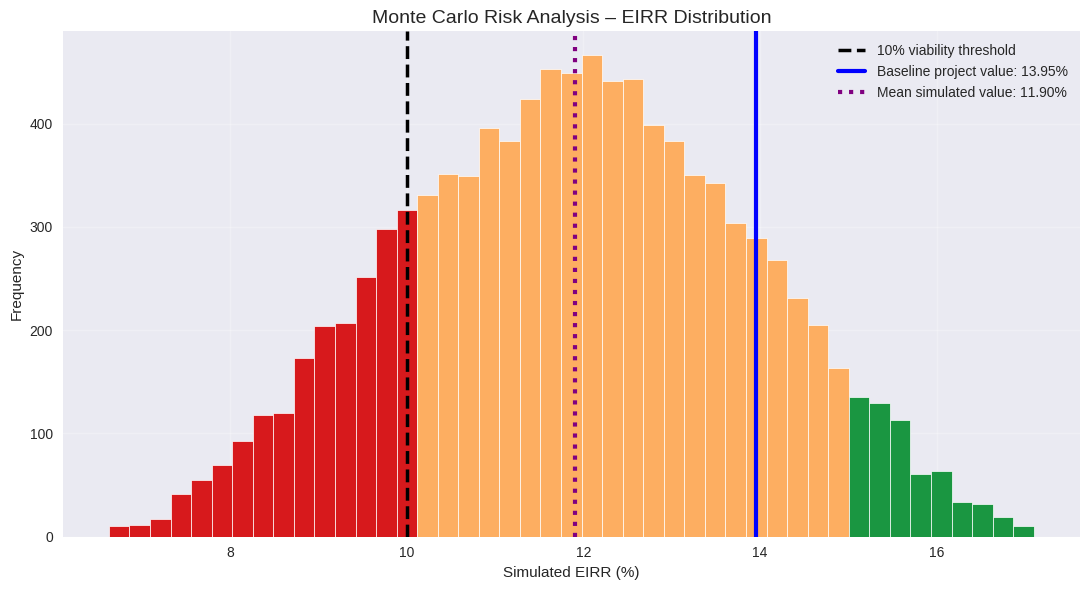

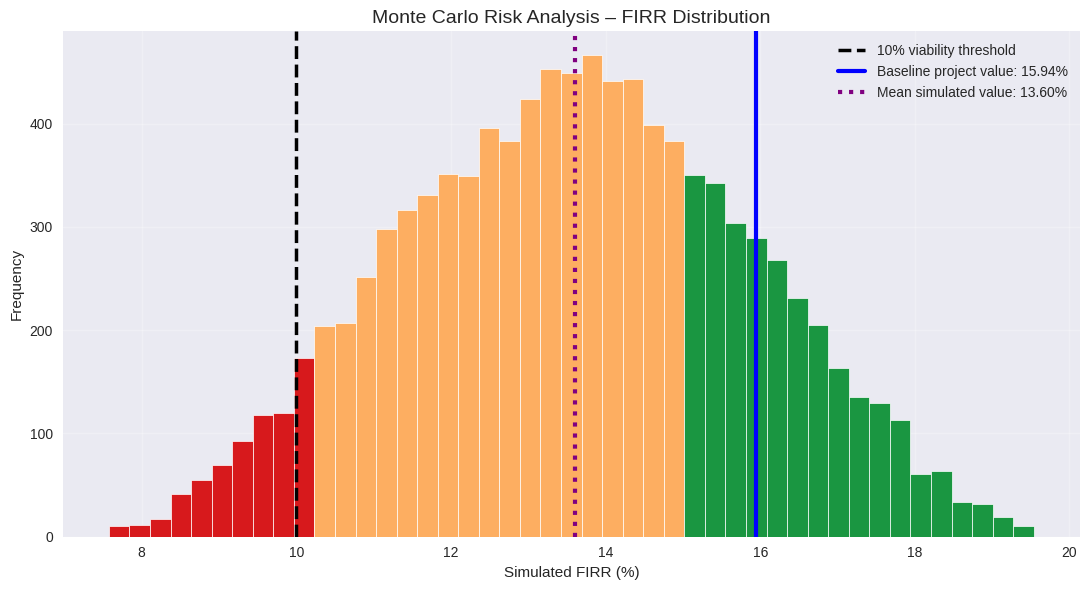

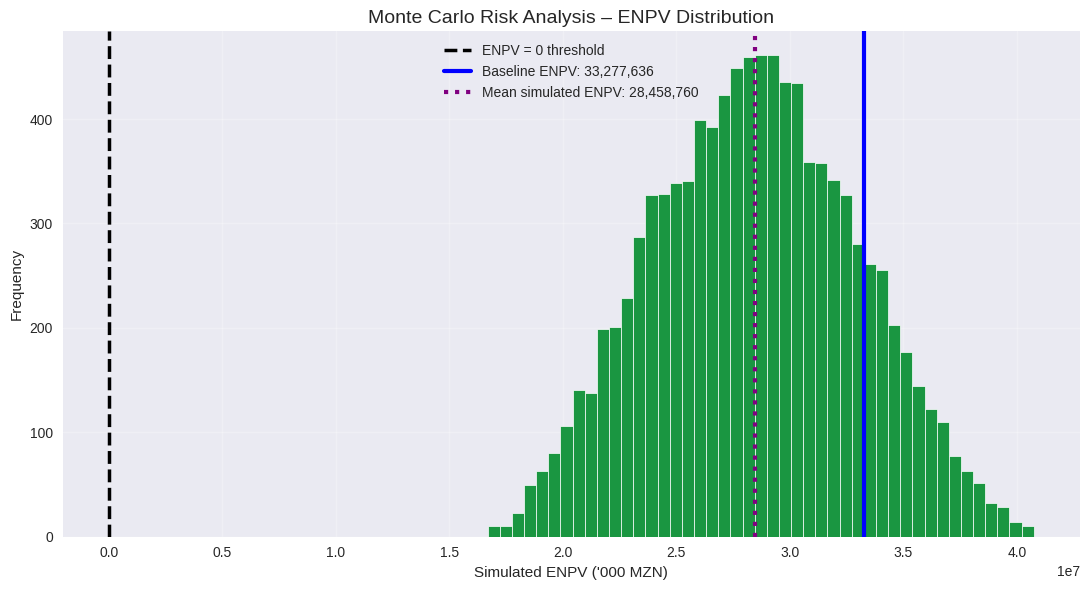

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# Monte Carlo Simulation with Risk Zoning
# =====================================================

np.random.seed(42)

n_simulations = 10000

# Baseline project results from your model
baseline_enpv = 33277635.78   # '000 MZN
baseline_fnpv = 39111303.46   # '000 MZN
baseline_eirr = 0.1395        # 13.95%
baseline_firr = 0.1594        # 15.94%

# Risk assumptions
cost_shock = np.random.uniform(-0.10, 0.20, n_simulations)
revenue_shock = np.random.uniform(-0.20, 0.15, n_simulations)
delay_shock = np.random.uniform(0.00, 0.15, n_simulations)

# Simulated values
simulated_enpv = baseline_enpv * (1 + revenue_shock) * (1 - delay_shock) - (baseline_enpv * cost_shock)
simulated_fnpv = baseline_fnpv * (1 + revenue_shock) * (1 - delay_shock) - (baseline_fnpv * cost_shock)

simulated_eirr = baseline_eirr * (1 + revenue_shock - cost_shock - delay_shock)
simulated_firr = baseline_firr * (1 + revenue_shock - cost_shock - delay_shock)

results = pd.DataFrame({
    "Simulated_ENPV": simulated_enpv,
    "Simulated_FNPV": simulated_fnpv,
    "Simulated_EIRR": simulated_eirr,
    "Simulated_FIRR": simulated_firr
})

# =====================================================
# Summary statistics
# =====================================================

print("Probability ENPV > 0:", round((results["Simulated_ENPV"] > 0).mean() * 100, 2), "%")
print("Probability FNPV > 0:", round((results["Simulated_FNPV"] > 0).mean() * 100, 2), "%")
print("Probability EIRR > 10%:", round((results["Simulated_EIRR"] > 0.10).mean() * 100, 2), "%")
print("Probability FIRR > 10%:", round((results["Simulated_FIRR"] > 0.10).mean() * 100, 2), "%")

print("\nMean EIRR:", round(results["Simulated_EIRR"].mean() * 100, 2), "%")
print("Mean FIRR:", round(results["Simulated_FIRR"].mean() * 100, 2), "%")

# =====================================================
# Function for risk-zoned histogram
# =====================================================

def plot_risk_distribution(series, baseline_value, title, xlabel, threshold=10):
    values = series * 100

    plt.figure(figsize=(11, 6))

    n, bins, patches = plt.hist(values, bins=45, edgecolor="white", linewidth=0.5)

    # Risk zoning colors
    for i in range(len(patches)):
        if bins[i] < threshold:
            patches[i].set_facecolor("#d7191c")   # Red: high risk
        elif bins[i] < 15:
            patches[i].set_facecolor("#fdae61")   # Orange: moderate risk
        else:
            patches[i].set_facecolor("#1a9641")   # Green: strong return

    # Threshold line
    plt.axvline(
        threshold,
        color="black",
        linestyle="--",
        linewidth=2.5,
        label=f"{threshold}% viability threshold"
    )

    # Baseline project line
    plt.axvline(
        baseline_value * 100,
        color="blue",
        linestyle="-",
        linewidth=3,
        label=f"Baseline project value: {baseline_value*100:.2f}%"
    )

    # Mean simulation line
    plt.axvline(
        values.mean(),
        color="purple",
        linestyle=":",
        linewidth=3,
        label=f"Mean simulated value: {values.mean():.2f}%"
    )

    plt.title(title, fontsize=14)
    plt.xlabel(xlabel)
    plt.ylabel("Frequency")

    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

# =====================================================
# EIRR Chart
# =====================================================

plot_risk_distribution(
    results["Simulated_EIRR"],
    baseline_eirr,
    "Monte Carlo Risk Analysis – EIRR Distribution",
    "Simulated EIRR (%)"
)

# =====================================================
# FIRR Chart
# =====================================================

plot_risk_distribution(
    results["Simulated_FIRR"],
    baseline_firr,
    "Monte Carlo Risk Analysis – FIRR Distribution",
    "Simulated FIRR (%)"
)

# =====================================================
# ENPV Distribution with project baseline
# =====================================================

plt.figure(figsize=(11, 6))

values = results["Simulated_ENPV"]

n, bins, patches = plt.hist(values, bins=45, edgecolor="white", linewidth=0.5)

for i in range(len(patches)):
    if bins[i] < 0:
        patches[i].set_facecolor("#d7191c")   # negative ENPV
    else:
        patches[i].set_facecolor("#1a9641")   # positive ENPV

plt.axvline(0, color="black", linestyle="--", linewidth=2.5, label="ENPV = 0 threshold")
plt.axvline(baseline_enpv, color="blue", linestyle="-", linewidth=3, label=f"Baseline ENPV: {baseline_enpv:,.0f}")
plt.axvline(values.mean(), color="purple", linestyle=":", linewidth=3, label=f"Mean simulated ENPV: {values.mean():,.0f}")

plt.title("Monte Carlo Risk Analysis – ENPV Distribution", fontsize=14)
plt.xlabel("Simulated ENPV ('000 MZN)")
plt.ylabel("Frequency")

plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

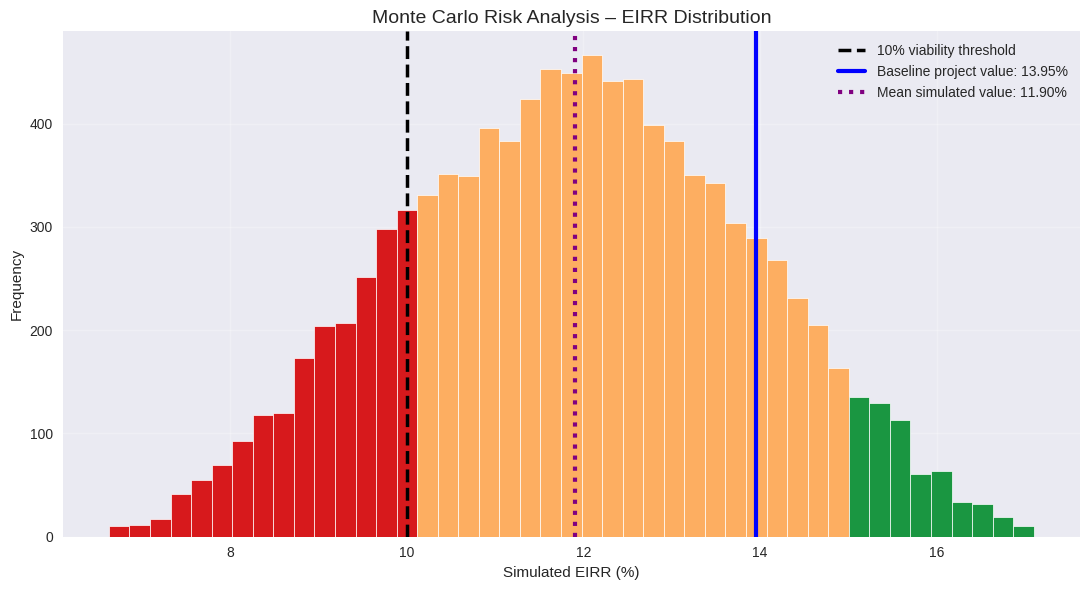

In [27]:
plot_risk_distribution(
    results["Simulated_EIRR"],
    baseline_eirr,
    "Monte Carlo Risk Analysis – EIRR Distribution",
    "Simulated EIRR (%)"
)

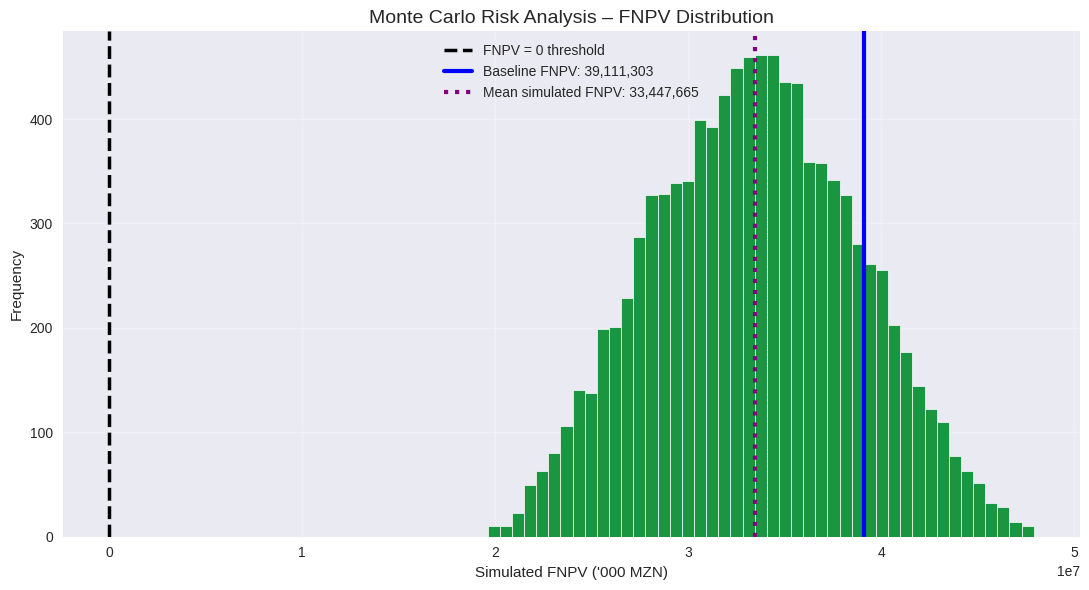

In [28]:
plt.figure(figsize=(11, 6))

values = results["Simulated_FNPV"]

n, bins, patches = plt.hist(values, bins=45, edgecolor="white", linewidth=0.5)

# Risk zones
for i in range(len(patches)):
    if bins[i] < 0:
        patches[i].set_facecolor("#d7191c")   # Red: negative NPV
    else:
        patches[i].set_facecolor("#1a9641")   # Green: positive NPV

# Threshold line
plt.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=2.5,
    label="FNPV = 0 threshold"
)

# Baseline project line
plt.axvline(
    baseline_fnpv,
    color="blue",
    linestyle="-",
    linewidth=3,
    label=f"Baseline FNPV: {baseline_fnpv:,.0f}"
)

# Mean simulation line
plt.axvline(
    values.mean(),
    color="purple",
    linestyle=":",
    linewidth=3,
    label=f"Mean simulated FNPV: {values.mean():,.0f}"
)

plt.title("Monte Carlo Risk Analysis – FNPV Distribution", fontsize=14)

plt.xlabel("Simulated FNPV ('000 MZN)")
plt.ylabel("Frequency")

plt.grid(alpha=0.25)

plt.legend()

plt.tight_layout()

plt.show()